# Pinterest Monte Carlo Revenue Simulation
### 10,000 Stochastic Scenarios Quantifying AI Disruption Risk

This notebook runs a Monte Carlo simulation to model the range of Pinterest's near-term revenue outcomes. Instead of picking a single growth forecast and hoping it's right, we sample 10,000 possible futures by varying six key parameters simultaneously — MAU growth, ARPU changes across three geographies, user engagement shifts, and ad pricing trends.

The result: a probability distribution that tells us not just *what might happen*, but *how likely each outcome is*.

**Data Source:** Pinterest 10-K filings (FY2024, FY2025), SEC EDGAR

---

## Setup & Configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Dark theme for all charts
DARK_BG = '#111827'
NAVY = '#0D1B3E'
BLUE = '#1565C0'
ACCENT = '#42A5F5'
LIGHT_BLUE = '#90CAF9'
GREEN = '#2E7D32'
RED = '#C62828'
GOLD = '#F9A825'
PURPLE = '#7B1FA2'
TEXT = '#C8D6E5'
MUTED = '#5C6B7A'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': '#1A2332',
    'axes.edgecolor': '#2A3A4E', 'axes.labelcolor': TEXT,
    'text.color': TEXT, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': '#1E2D3D', 'grid.alpha': 0.5,
    'font.family': 'sans-serif', 'font.size': 11,
})

dollar_fmt = FuncFormatter(lambda x, p: f'${x:,.0f}M')
pct_fmt = FuncFormatter(lambda x, p: f'{x:.0%}')
print('Libraries loaded.')

Libraries loaded.


## Simulation Parameters

Each parameter is drawn from a normal distribution. The means and standard deviations are calibrated from Pinterest's actual 2021–2025 performance and forward-looking risk factors disclosed in the 10-K.

| Parameter | Mean | Std Dev | Rationale |
|-----------|------|---------|-----------|
| US ARPU Growth | +3% | 6% | Mature market, slowing; 10-K shows deceleration from 14% to 6% |
| Europe ARPU Growth | +15% | 8% | Strong momentum (+21% in 2025), but volatile |
| ROW ARPU Growth | +25% | 10% | Fastest growing (+40% in 2025), highest uncertainty |
| MAU Growth | +8% | 4% | Steady at ~11-12%, but AI could disrupt discovery |
| Engagement Change | -3% | 7% | Slightly negative mean reflects AI displacement risk |
| Ad Price Change | -10% | 8% | Prices have declined 14-22% annually — structural trend |

In [ ]:
np.random.seed(42)
N = 10_000  # simulations

# 2025 actuals (from 10-K)
BASE = {'us': 3173, 'eu': 775, 'row': 274, 'total': 4222}

params = {
    'us_arpu_growth':  {'mean': 0.03,  'std': 0.06},
    'eu_arpu_growth':  {'mean': 0.15,  'std': 0.08},
    'row_arpu_growth': {'mean': 0.25,  'std': 0.10},
    'mau_growth':      {'mean': 0.08,  'std': 0.04},
    'engagement_chg':  {'mean': -0.03, 'std': 0.07},
    'ad_price_chg':    {'mean': -0.10, 'std': 0.08},
}

print(f'Running {N:,} simulations...')
print(f'Base revenue: ${BASE["total"]:,}M (FY2025)')

Running 10,000 simulations...
Base revenue: $4,222M (FY2025)


## Running the Simulation

In [ ]:
results = []
for _ in range(N):
    d = {k: np.random.normal(v['mean'], v['std']) for k, v in params.items()}
    vol = (1 + d['mau_growth']) * (1 + d['engagement_chg'])
    us  = BASE['us']  * vol * (1 + d['us_arpu_growth'])
    eu  = BASE['eu']  * vol * (1 + d['eu_arpu_growth'])
    row = BASE['row'] * vol * (1 + d['row_arpu_growth'])
    results.append({'total': us+eu+row, 'us': us, 'eu': eu, 'row': row, **d})

df = pd.DataFrame(results)

# Key statistics
stats = {
    'Mean':     df['total'].mean(),
    'Median':   df['total'].median(),
    'Std Dev':  df['total'].std(),
    '5th %ile': df['total'].quantile(0.05),
    '95th %ile':df['total'].quantile(0.95),
}

print('=' * 50)
print('SIMULATION RESULTS')
print('=' * 50)
for k, v in stats.items():
    print(f'  {k:12s}  ${v:,.0f}M')
print()
print(f'  P(Rev < $4.0B):  {(df["total"] < 4000).mean():.1%}')
print(f'  P(Rev < current): {(df["total"] < 4222).mean():.1%}')
print(f'  P(Rev > $5.0B):  {(df["total"] > 5000).mean():.1%}')

SIMULATION RESULTS
  Mean          $4,714M
  Median        $4,708M
  Std Dev       $440M
  5th %ile      $4,011M
  95th %ile     $5,456M

  P(Rev < $4.0B):  4.7%
  P(Rev < current): 13.0%
  P(Rev > $5.0B):  25.1%


## Revenue Distribution

The histogram below shows the full probability distribution. Red bars represent outcomes below current revenue (a decline scenario). Green bars represent outcomes above $5B. The white dotted line marks where Pinterest is today.

**Key read:** The distribution is roughly normal but slightly right-skewed — there's more upside than downside in absolute terms, but the ~13% probability of revenue *declining* from current levels is the strategic risk that matters.

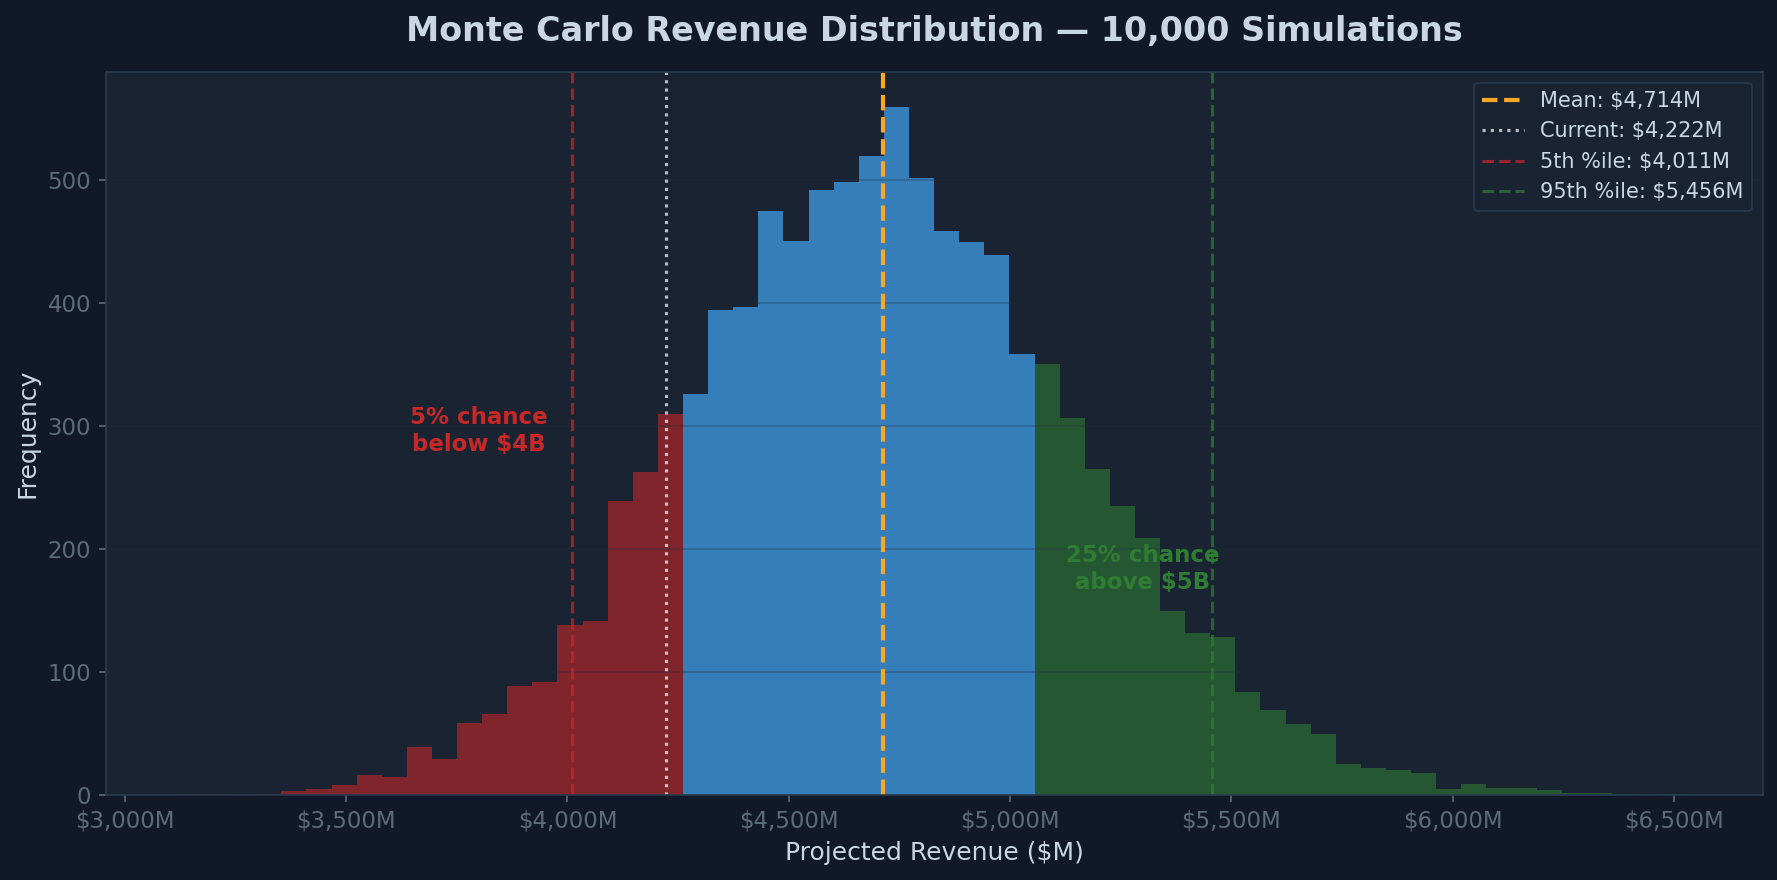

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
n, bins, patches = ax.hist(df['total'], bins=60, color=ACCENT, alpha=0.7, edgecolor='none')
for patch, edge in zip(patches, bins[:-1]):
    if edge < 4222: patch.set_facecolor(RED); patch.set_alpha(0.6)
    elif edge > 5000: patch.set_facecolor(GREEN); patch.set_alpha(0.6)

ax.axvline(df['total'].mean(), color=GOLD, lw=2, ls='--', label=f'Mean: ${df["total"].mean():,.0f}M')
ax.axvline(4222, color='white', lw=1.5, ls=':', alpha=0.7, label='Current: $4,222M')
ax.axvline(df['total'].quantile(0.05), color=RED, lw=1.5, ls='--', alpha=0.7, label=f'5th: ${df["total"].quantile(0.05):,.0f}M')
ax.axvline(df['total'].quantile(0.95), color=GREEN, lw=1.5, ls='--', alpha=0.7, label=f'95th: ${df["total"].quantile(0.95):,.0f}M')
ax.set_xlabel('Projected Revenue ($M)'); ax.set_ylabel('Frequency')
ax.set_title('Monte Carlo Revenue Distribution — 10,000 Simulations', fontsize=16, pad=15)
ax.xaxis.set_major_formatter(dollar_fmt)
ax.legend(fontsize=10, facecolor='#1A2332', edgecolor='#2A3A4E', labelcolor=TEXT)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Tornado Chart — What Moves the Needle?

This chart ranks each input parameter by how much it swings the revenue outcome. We compare the mean revenue when each parameter is at its 10th percentile (bad) vs 90th percentile (good).

**Key read:** Engagement change is the #1 driver — a $1.2B spread. This is exactly the AI disruption risk: if generative AI pulls users away from Pinterest, engagement drops, ad inventory shrinks, and revenue follows. US ARPU growth is #2, confirming the revenue concentration risk.

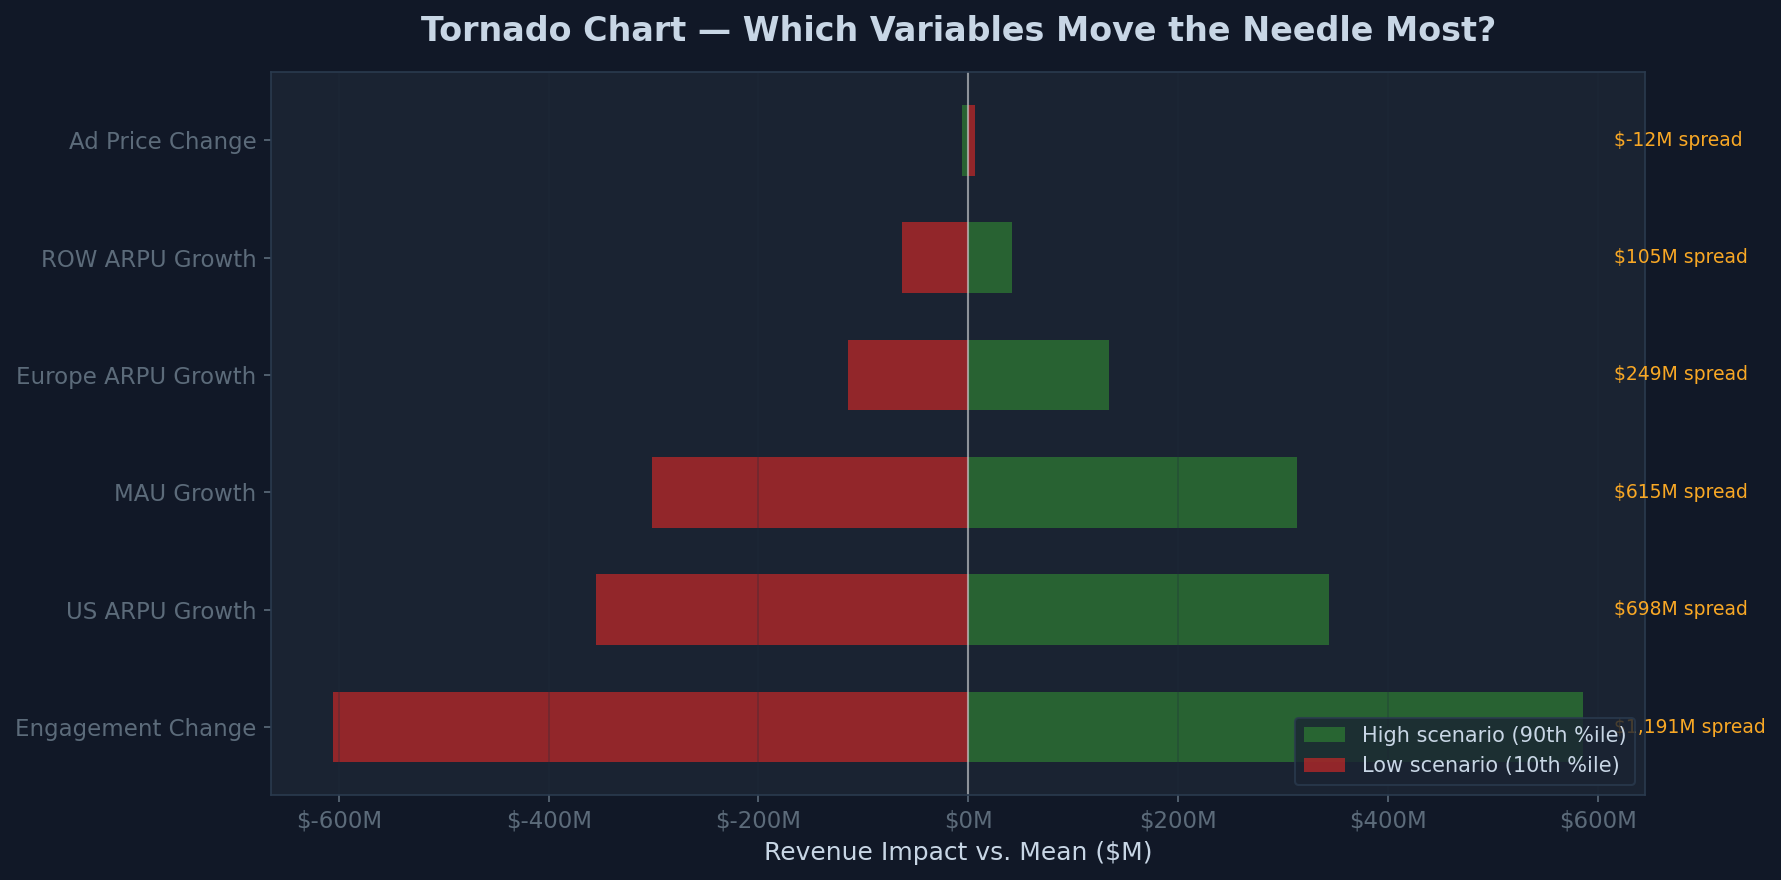

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
labels_map = {'engagement_chg': 'Engagement Change', 'us_arpu_growth': 'US ARPU Growth',
              'mau_growth': 'MAU Growth', 'eu_arpu_growth': 'Europe ARPU Growth',
              'row_arpu_growth': 'ROW ARPU Growth', 'ad_price_chg': 'Ad Price Change'}
sens = {}
for k, label in labels_map.items():
    lo = df.loc[df[k] <= df[k].quantile(0.10), 'total'].mean()
    hi = df.loc[df[k] >= df[k].quantile(0.90), 'total'].mean()
    sens[label] = (lo - df['total'].mean(), hi - df['total'].mean(), hi - lo)

sorted_s = sorted(sens.items(), key=lambda x: x[1][2], reverse=True)
labels = [s[0] for s in sorted_s]
lows = [s[1][0] for s in sorted_s]; highs = [s[1][1] for s in sorted_s]
y = range(len(labels))
ax.barh(y, highs, height=0.6, color=GREEN, alpha=0.7, label='High (90th %ile)')
ax.barh(y, lows, height=0.6, color=RED, alpha=0.7, label='Low (10th %ile)')
ax.axvline(0, color='white', lw=1, alpha=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Revenue Impact vs. Mean ($M)')
ax.set_title('Tornado Chart — Which Variables Move the Needle Most?', fontsize=16, pad=15)
ax.xaxis.set_major_formatter(dollar_fmt)
ax.legend(fontsize=10, loc='lower right', facecolor='#1A2332', edgecolor='#2A3A4E', labelcolor=TEXT)
for i, (_, vals) in enumerate(sorted_s):
    ax.annotate(f'${vals[2]:,.0f}M', xy=(max(highs)+30, i), fontsize=9, color=GOLD, va='center')
plt.tight_layout(); plt.show()

## Regional Revenue Distribution

Violin plots showing the simulated revenue distribution for each geography. The diamonds mark 2025 actuals.

**Key read:** US & Canada dominates the risk profile — its distribution is widest in absolute terms. But ROW and Europe show meaningful upside tails, reflecting the ARPU convergence opportunity.

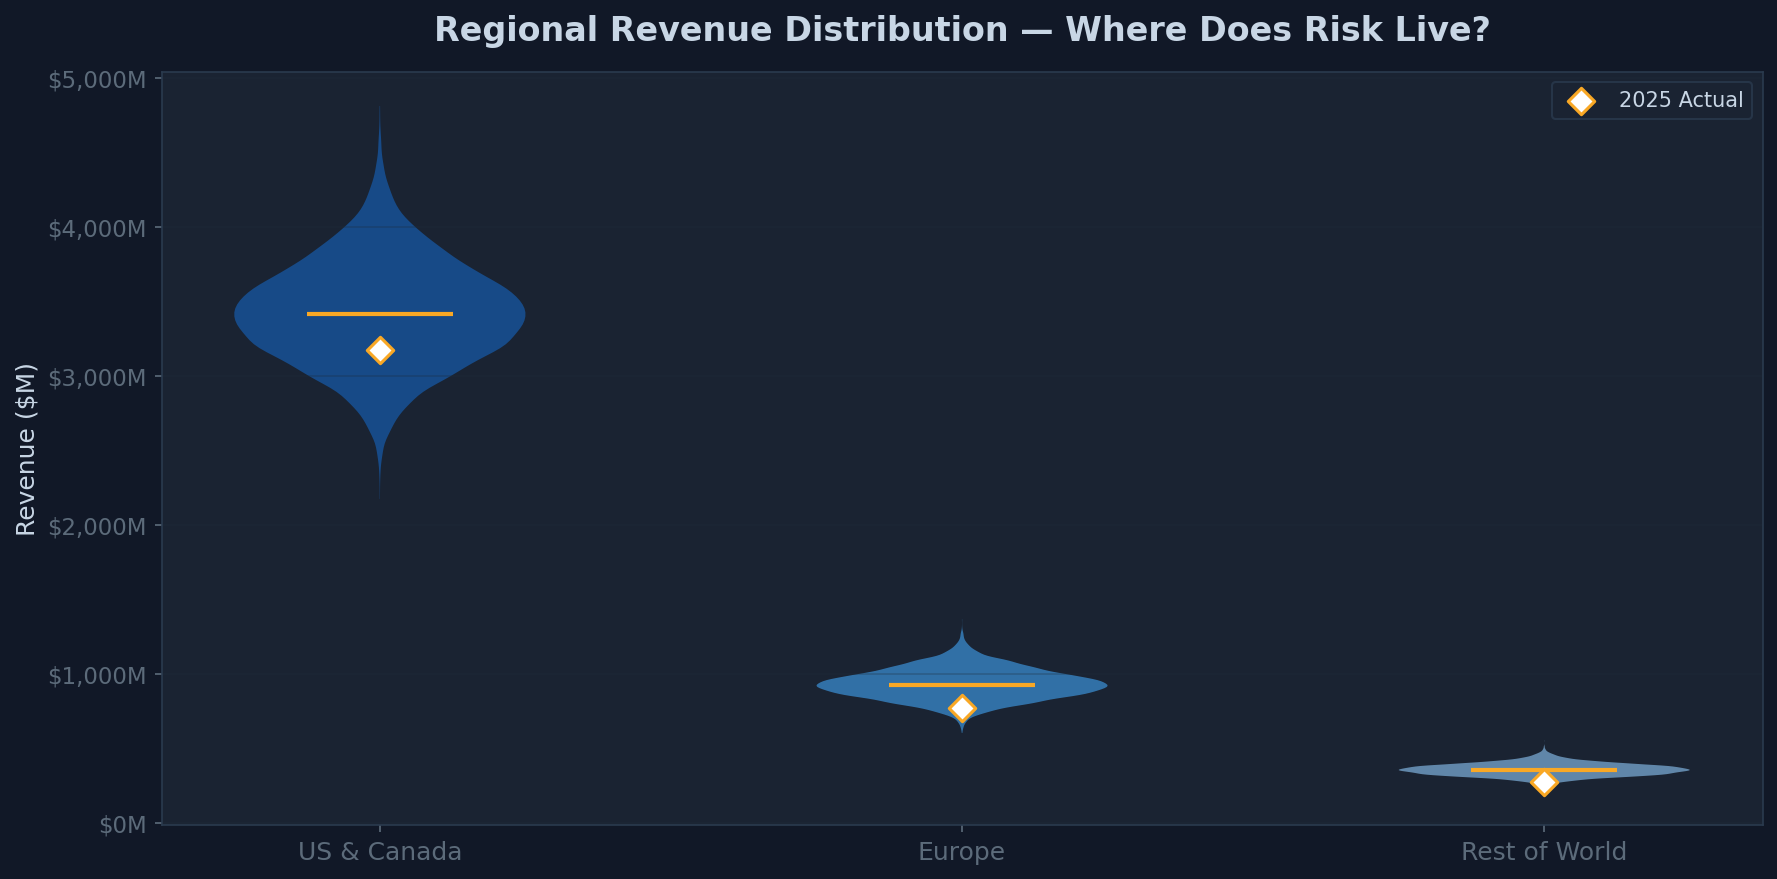

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
parts = ax.violinplot([df['us'], df['eu'], df['row']], positions=[1,2,3], showmedians=True, showextrema=False)
for i, (pc, color) in enumerate(zip(parts['bodies'], [BLUE, ACCENT, LIGHT_BLUE])):
    pc.set_facecolor(color); pc.set_alpha(0.6)
parts['cmedians'].set_color(GOLD); parts['cmedians'].set_linewidth(2)
for i, val in enumerate([3173, 775, 274]):
    ax.scatter(i+1, val, color='white', s=80, zorder=5, marker='D', edgecolors=GOLD, linewidths=1.5)
ax.set_xticks([1,2,3]); ax.set_xticklabels(['US & Canada','Europe','Rest of World'], fontsize=12)
ax.set_ylabel('Revenue ($M)'); ax.yaxis.set_major_formatter(dollar_fmt)
ax.set_title('Regional Revenue Distribution — Where Does Risk Live?', fontsize=16, pad=15)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Cumulative Probability (S-Curve)

Read this chart by picking a revenue number on the x-axis and reading up to the curve — that's the probability of landing *at or below* that number.

**Key read:** There's a ~13% chance revenue falls below current levels, and a ~25% chance it exceeds $5B. The curve is steepest between $4.2B and $5.0B, meaning that's where most outcomes cluster.

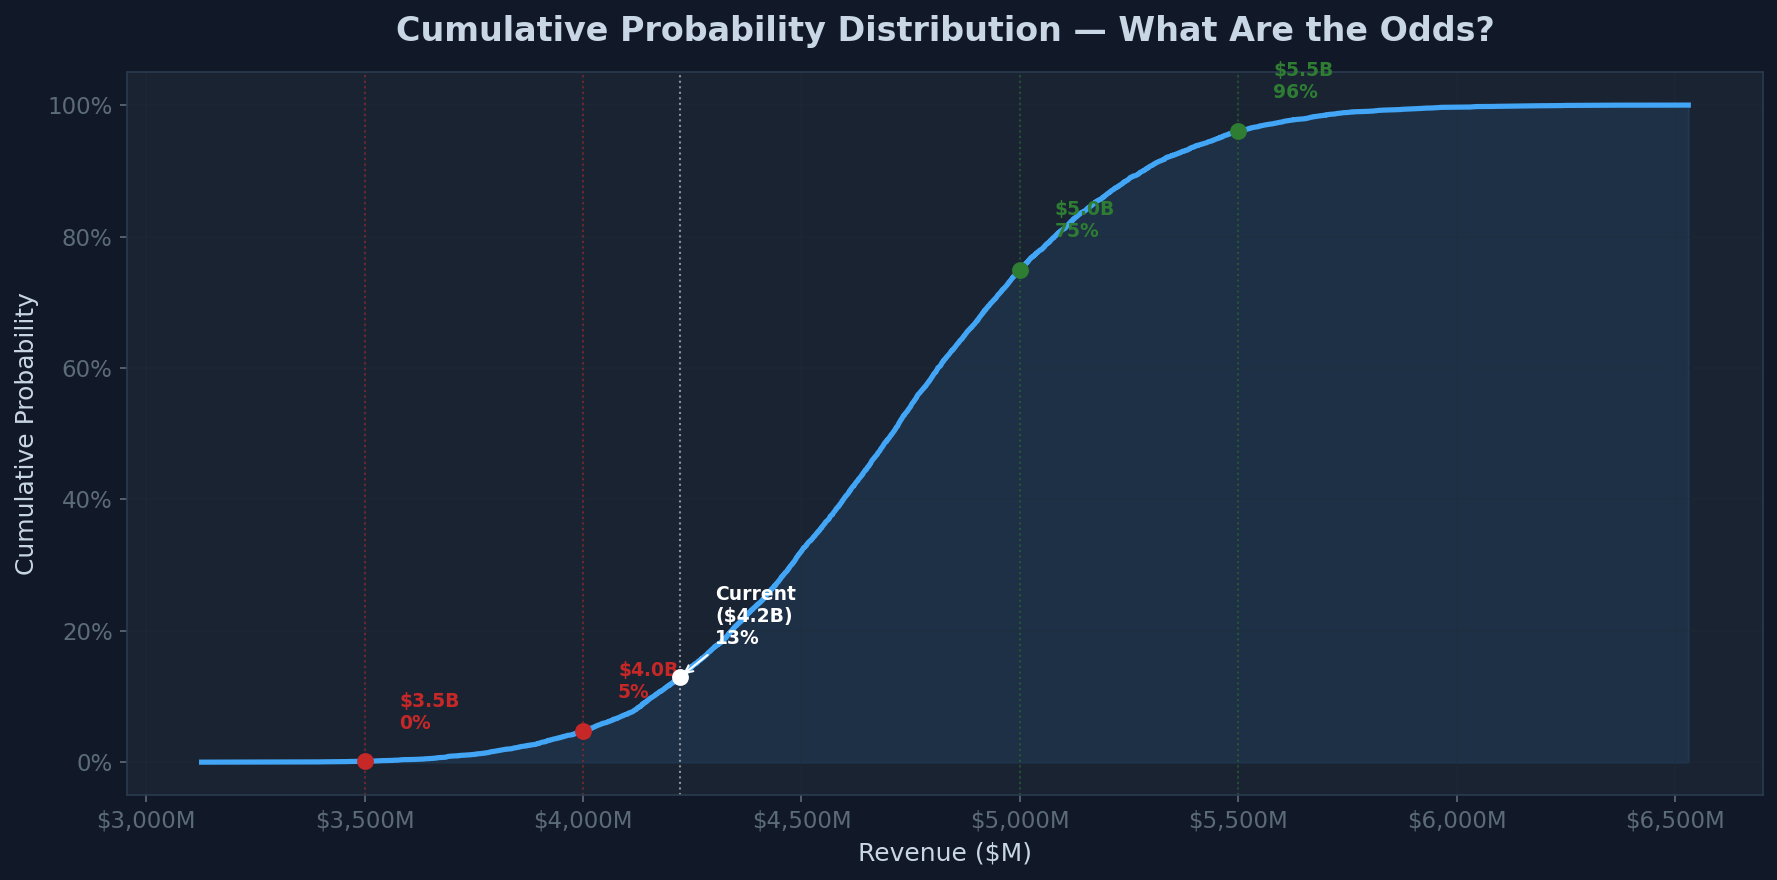

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
s = np.sort(df['total']); cp = np.arange(1, len(s)+1)/len(s)
ax.plot(s, cp, color=ACCENT, lw=2.5); ax.fill_between(s, cp, alpha=0.1, color=ACCENT)
for thr, lbl, clr in [(3500,'$3.5B',RED),(4000,'$4.0B',RED),(4222,'Current ($4.2B)','white'),(5000,'$5.0B',GREEN),(5500,'$5.5B',GREEN)]:
    p = (df['total']<=thr).mean()
    ax.axvline(thr, color=clr, lw=1, ls=':', alpha=0.5)
    ax.scatter(thr, p, color=clr, s=50, zorder=5)
    ax.annotate(f'{lbl}\n{p:.0%}', xy=(thr,p), xytext=(thr+80,p+0.05), fontsize=9, color=clr, fontweight='bold')
ax.set_xlabel('Revenue ($M)'); ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Probability — What Are the Odds?', fontsize=16, pad=15)
ax.xaxis.set_major_formatter(dollar_fmt); ax.yaxis.set_major_formatter(pct_fmt)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Parameter Correlations

Since all parameters are drawn independently, correlations should be near zero — confirming the simulation is well-constructed. Any real-world correlation (e.g., MAU growth and engagement tend to move together) would be a model enhancement for v2.

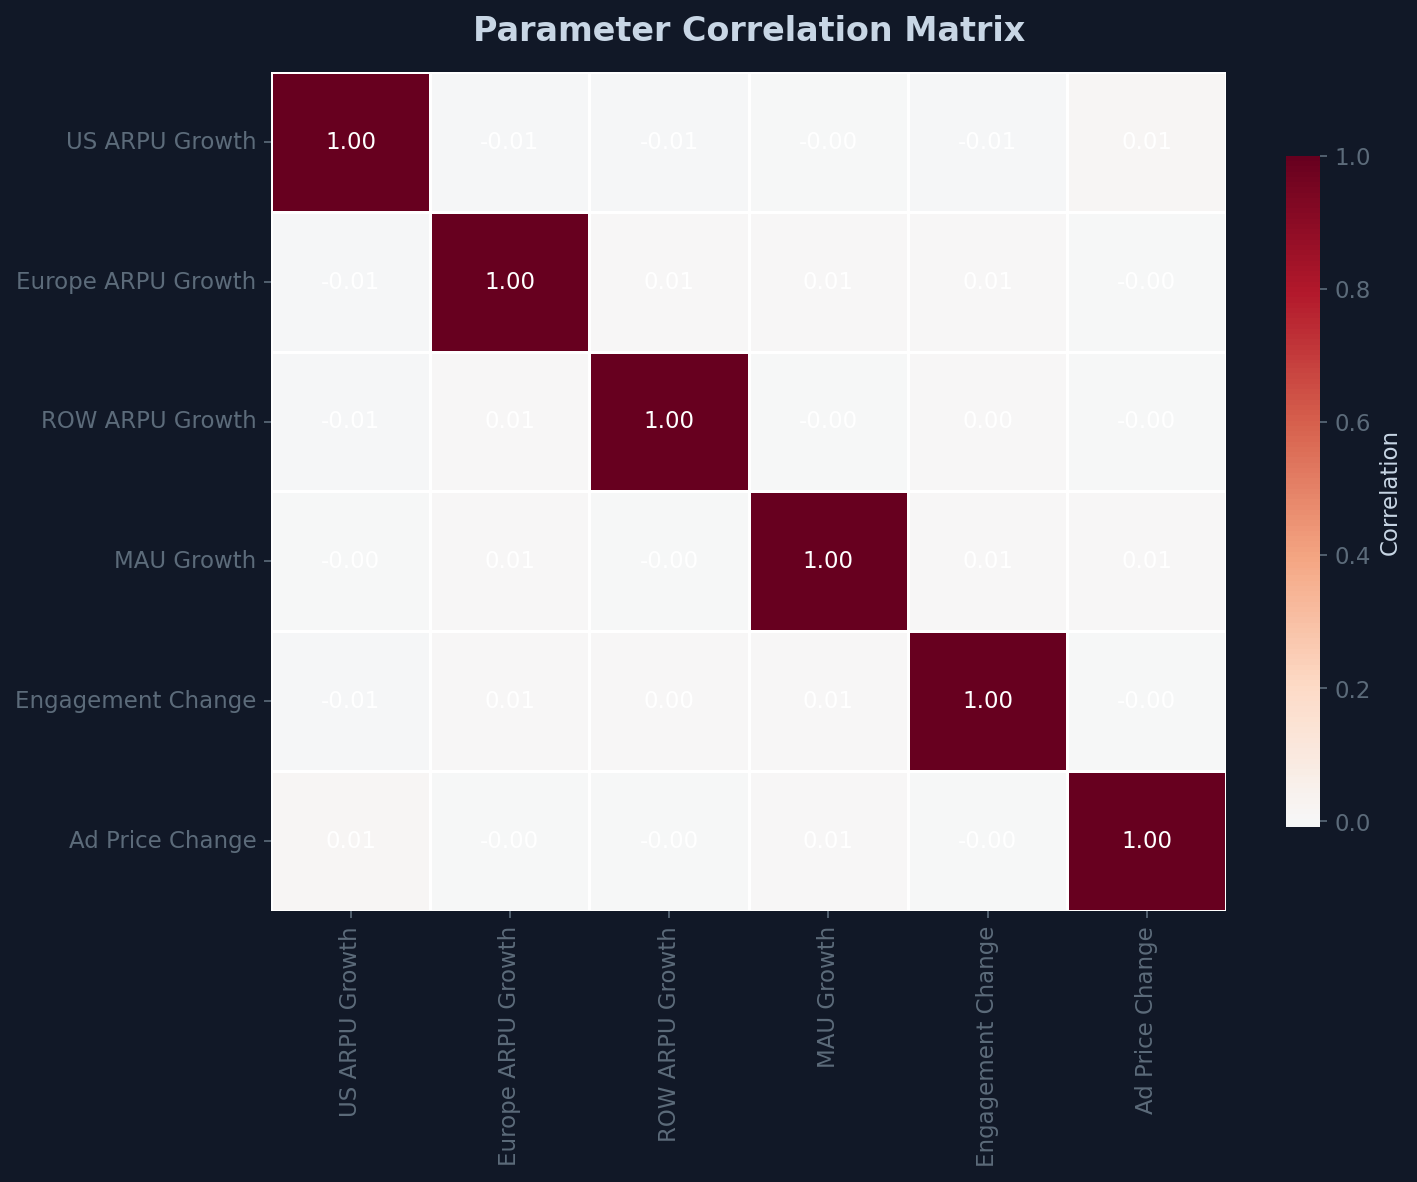

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cols = list(params.keys())
lbls = ['US ARPU Growth','EU ARPU Growth','ROW ARPU Growth','MAU Growth','Engagement Chg','Ad Price Chg']
cm = df[cols].corr(); cm.index = lbls; cm.columns = lbls
sns.heatmap(cm, annot=True, fmt='.2f', center=0, cmap='RdBu_r', ax=ax, linewidths=0.5,
            annot_kws={'size':11,'color':'white'}, cbar_kws={'label':'Correlation','shrink':0.8})
ax.set_title('Parameter Correlation Matrix', fontsize=16, pad=15)
plt.tight_layout(); plt.show()

## Revenue vs. Key Drivers (Scatter + Trendline)

Each dot is one simulation. The yellow dashed line is the linear fit. The slope tells you how sensitive revenue is to each driver.

**Key read:** MAU Growth and Engagement Change have the steepest slopes and tightest correlation — these are the variables Pinterest leadership should be monitoring obsessively.

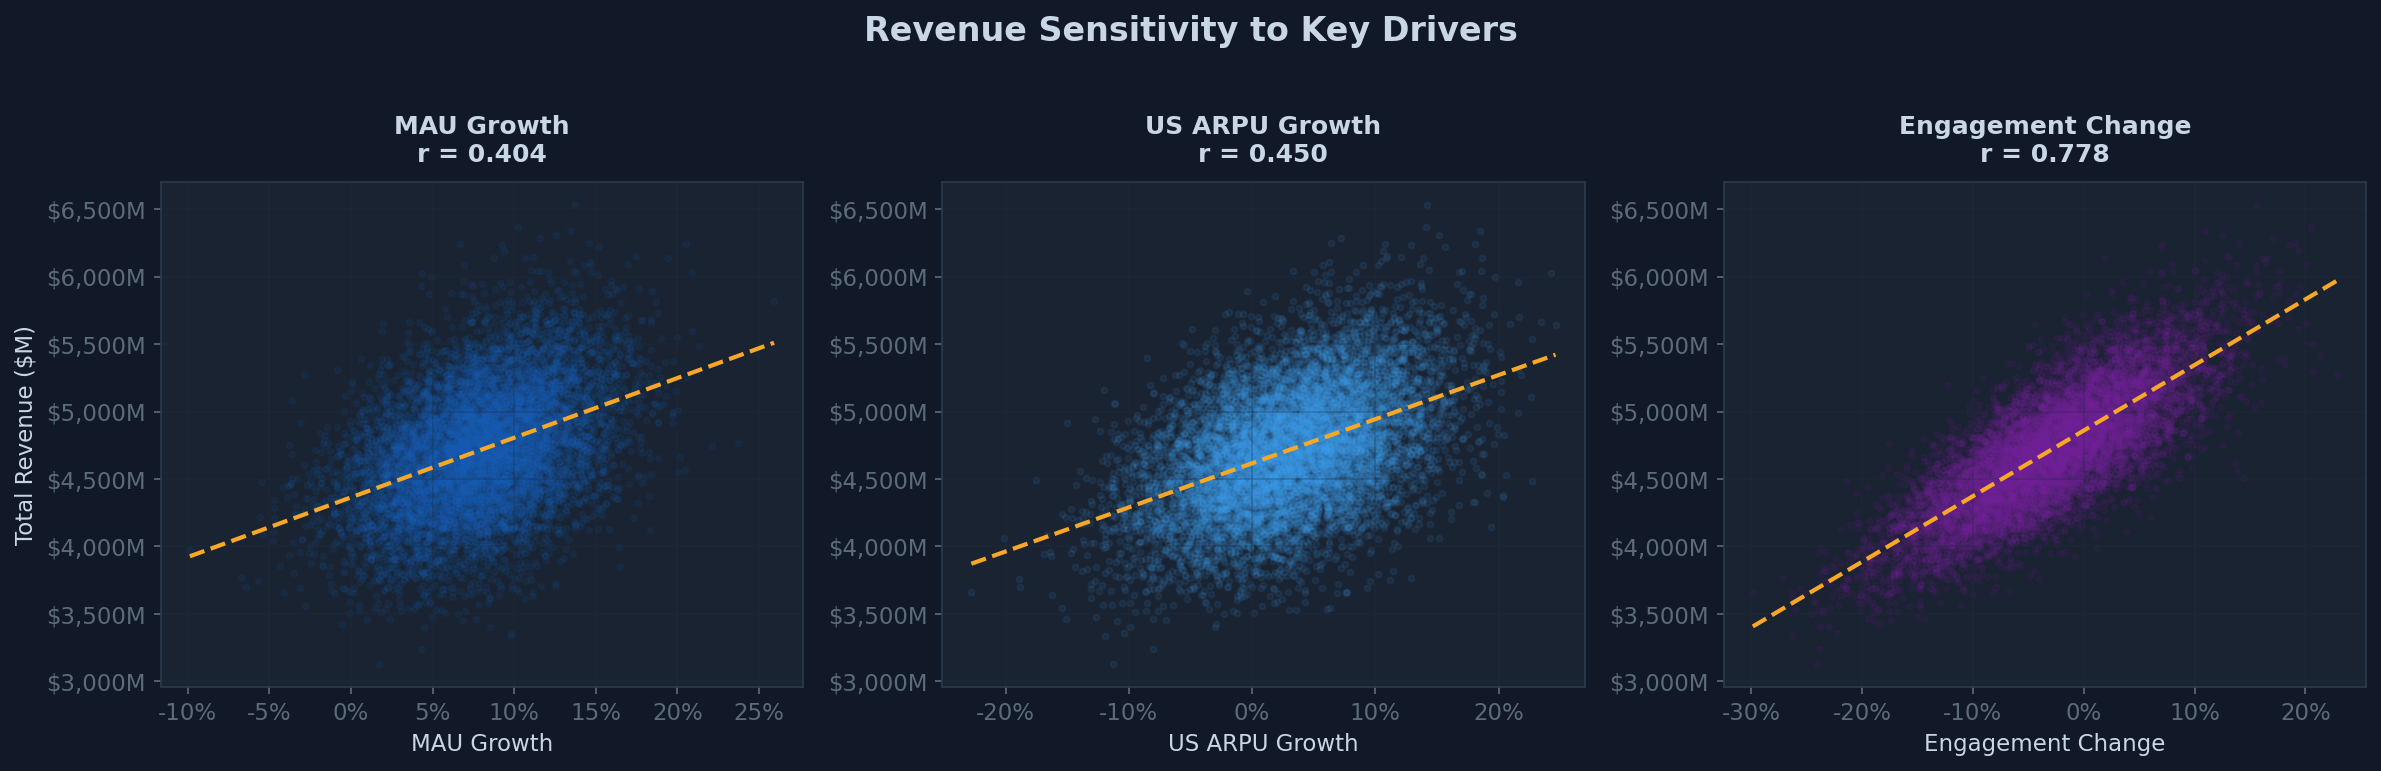

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (p, lbl, clr) in zip(axes, [('mau_growth','MAU Growth',BLUE),('us_arpu_growth','US ARPU Growth',ACCENT),('engagement_chg','Engagement Chg',PURPLE)]):
    ax.scatter(df[p], df['total'], alpha=0.08, s=8, color=clr)
    z = np.polyfit(df[p], df['total'], 1); x = np.linspace(df[p].min(), df[p].max(), 100)
    ax.plot(x, np.poly1d(z)(x), color=GOLD, lw=2, ls='--')
    ax.set_xlabel(lbl); ax.set_ylabel('Revenue ($M)' if ax==axes[0] else '')
    ax.xaxis.set_major_formatter(pct_fmt); ax.yaxis.set_major_formatter(dollar_fmt)
    ax.set_title(f'{lbl}\nr = {df[p].corr(df["total"]):.3f}', fontsize=12, pad=10)
    ax.grid(True, alpha=0.3)
fig.suptitle('Revenue Sensitivity to Key Drivers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Key Takeaways

1. **Expected revenue is ~$4.7B** — roughly 12% above current levels. The base case is growth, not decline.

2. **But 13% of simulations show revenue falling below today's $4.2B.** That's not catastrophic, but it's not comfortable.

3. **Engagement is the #1 risk variable**, with a $1.2B revenue spread between pessimistic and optimistic outcomes. This is directly where AI disruption would hit — if users shift discovery behavior to chatbots, engagement drops and ad inventory collapses.

4. **US ARPU is the #2 driver**, confirming that Pinterest's 75% US revenue concentration creates outsized sensitivity to domestic market conditions.

5. **The 90% confidence interval ($4.0B – $5.5B)** gives leadership a planning range. Anything below $4B should trigger contingency planning; anything above $5.5B suggests the AI integration strategy is working.

---
*Data: Pinterest 10-K (FY2024, FY2025). Not investment advice.*